In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [5]:
url2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
X = pd.read_csv(url2)
print("Shape:", X.shape)
X.head()

Shape: (90, 83)


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [6]:
Y = df['Class'].to_numpy()
print("Y shape:", Y.shape)
print("Y values:", Y[:10])

Y shape: (90,)
Y values: [0 0 0 0 0 0 1 1 0 0]


In [7]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
print("✅ Features standardized!")
print("X shape:", X.shape)

✅ Features standardized!
X shape: (90, 83)


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (72, 83)
X_test shape: (18, 83)
Y_train shape: (72,)
Y_test shape: (18,)


In [9]:
# Logistic Regression with GridSearchCV
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, Y_train)

print("Logistic Regression:")
print("Best Parameters:", logreg_cv.best_params_)
print("Best CV Score:", logreg_cv.best_score_)
print("Test Accuracy:", logreg_cv.score(X_test, Y_test))

Logistic Regression:
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.8464285714285713
Test Accuracy: 0.8333333333333334


In [10]:
# SVM with GridSearchCV
parameters_svm = {'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
                  'C': [0.1, 1, 10]}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, Y_train)

print("Support Vector Machine:")
print("Best Parameters:", svm_cv.best_params_)
print("Best CV Score:", svm_cv.best_score_)
print("Test Accuracy:", svm_cv.score(X_test, Y_test))

Support Vector Machine:
Best Parameters: {'C': 1, 'kernel': 'sigmoid'}
Best CV Score: 0.8482142857142858
Test Accuracy: 0.8333333333333334


In [11]:
# Decision Tree with GridSearchCV
parameters_dt = {'criterion': ['gini', 'entropy'],
                 'splitter': ['best', 'random'],
                 'max_depth': [2, 4, 6, 8, 10],
                 'max_features': ['auto', 'sqrt'],
                 'min_samples_leaf': [1, 2, 4],
                 'min_samples_split': [2, 5, 10]}
dt = DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, parameters_dt, cv=10)
dt_cv.fit(X_train, Y_train)

print("Decision Tree:")
print("Best Parameters:", dt_cv.best_params_)
print("Best CV Score:", dt_cv.best_score_)
print("Test Accuracy:", dt_cv.score(X_test, Y_test))

Decision Tree:
Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}
Best CV Score: 0.875
Test Accuracy: 0.8333333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1800 fits failed out of a total of 3600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1800 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/u

In [12]:
# KNN with GridSearchCV
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                  'p': [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, Y_train)

print("K-Nearest Neighbors:")
print("Best Parameters:", knn_cv.best_params_)
print("Best CV Score:", knn_cv.best_score_)
print("Test Accuracy:", knn_cv.score(X_test, Y_test))

K-Nearest Neighbors:
Best Parameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Best CV Score: 0.8482142857142858
Test Accuracy: 0.8333333333333334


In [13]:
print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Logistic Regression  - CV Score: {logreg_cv.best_score_:.4f} | Test Accuracy: {logreg_cv.score(X_test, Y_test):.4f}")
print(f"SVM                  - CV Score: {svm_cv.best_score_:.4f} | Test Accuracy: {svm_cv.score(X_test, Y_test):.4f}")
print(f"Decision Tree        - CV Score: {dt_cv.best_score_:.4f} | Test Accuracy: {dt_cv.score(X_test, Y_test):.4f}")
print(f"KNN                  - CV Score: {knn_cv.best_score_:.4f} | Test Accuracy: {knn_cv.score(X_test, Y_test):.4f}")

MODEL COMPARISON
Logistic Regression  - CV Score: 0.8464 | Test Accuracy: 0.8333
SVM                  - CV Score: 0.8482 | Test Accuracy: 0.8333
Decision Tree        - CV Score: 0.8750 | Test Accuracy: 0.8333
KNN                  - CV Score: 0.8482 | Test Accuracy: 0.8333


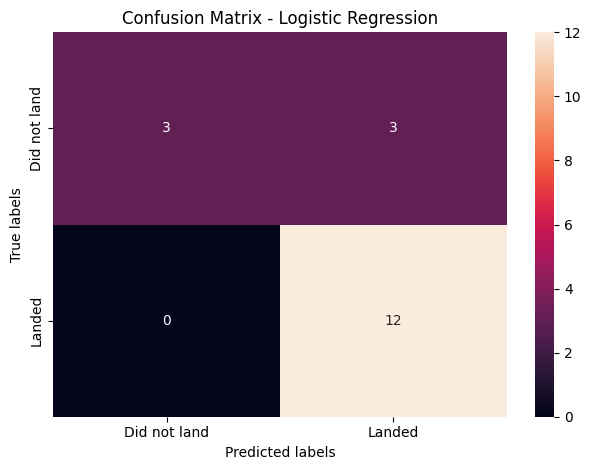

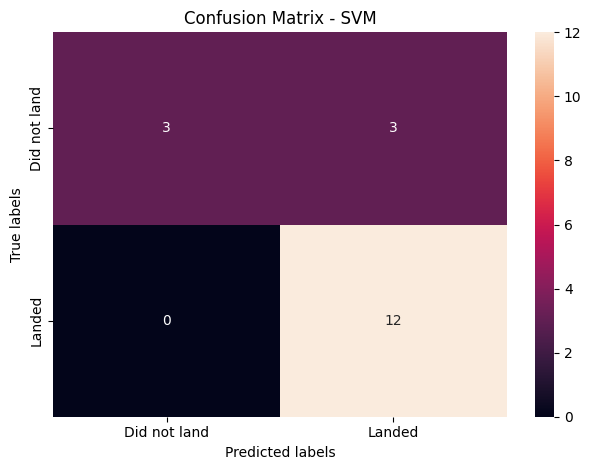

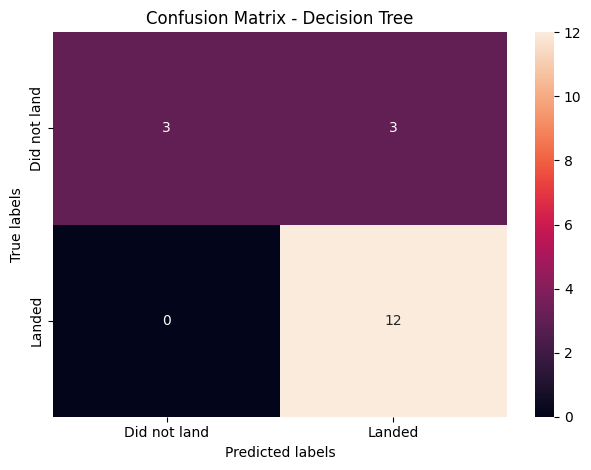

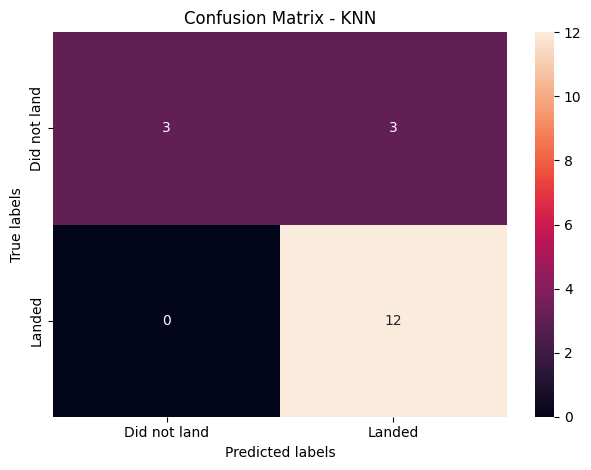

In [14]:
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='g')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(f'Confusion Matrix - {title}')
    ax.xaxis.set_ticklabels(['Did not land', 'Landed'])
    ax.yaxis.set_ticklabels(['Did not land', 'Landed'])
    plt.tight_layout()
    plt.show()

# Plot confusion matrix for all models
plot_confusion_matrix(Y_test, logreg_cv.predict(X_test), 'Logistic Regression')
plot_confusion_matrix(Y_test, svm_cv.predict(X_test), 'SVM')
plot_confusion_matrix(Y_test, dt_cv.predict(X_test), 'Decision Tree')
plot_confusion_matrix(Y_test, knn_cv.predict(X_test), 'KNN')